# Aula 03 — Junção de Dados e Pipeline Completo de Limpeza (Revisão)

**Semana 06 · Dia 03 (Sexta-feira) · SENAI — Visualização de Dados**

Sexta é dia de **revisão e consolidação**. Hoje vamos fechar a semana com dois tópicos novos e depois construir juntos um **pipeline completo** de limpeza de dados.

**O que vamos fazer hoje:**

1. **Concatenação** — empilhar DataFrames com `pd.concat()`
2. **Merge/Join** — cruzar tabelas com `pd.merge()` (como SQL JOIN)
3. **Pipeline completo** — aplicar tudo que aprendemos na semana do zero ao clean
4. **Exercício de revisão** da Semana 06

## Bloco 0 — Setup

Carregamos a base e preparamos algumas tabelas auxiliares para os exemplos de merge.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("../base/base_vendas_supermercado.xlsx")

print(f"Base carregada: {df.shape[0]} linhas x {df.shape[1]} colunas")
print()
print("Colunas:", df.columns.tolist())
print()
print("Categorias:", df['Categoria'].unique().tolist())
print("Lojas:", df['Loja'].unique().tolist())

Base carregada: 250 linhas x 12 colunas

Colunas: ['Data', 'Loja', 'Cliente', 'Categoria', 'Produto', 'Quantidade', 'Preço Unitário', 'Desconto %', 'Valor Bruto', 'Valor Desconto', 'Valor Líquido', 'Forma de Pagamento']

Categorias: ['Laticínios', 'Mercearia', 'Padaria', 'Hortifruti', 'Limpeza', 'Açougue', 'Frios', 'Higiene', 'Bebidas']
Lojas: ['Loja Shopping', 'Loja Centro', 'Loja Norte', 'Loja Bairro Alto']


C:\Users\waldinei.rosa\AppData\Roaming\Python\Python313\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
C:\Users\waldinei.rosa\AppData\Roaming\Python\Python313\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


## Bloco 1 — Concatenação: Empilhando DataFrames

### Quando usar `pd.concat()`?

Imagine que você recebeu os dados de **Janeiro** e **Fevereiro** em arquivos separados. Para analisar os dois meses juntos, você precisa **empilhar** os dois DataFrames — um embaixo do outro. Isso é concatenação.

`pd.concat([df1, df2], ignore_index=True)` — a opção `ignore_index=True` reinicia a numeração das linhas.

In [2]:
# Dividindo nossa base por mês para simular dois arquivos separados
df['Mes'] = df['Data'].dt.month

df_jan = df[df['Mes'] == 1].drop(columns='Mes').reset_index(drop=True)
df_fev = df[df['Mes'] == 2].drop(columns='Mes').reset_index(drop=True)
df_mar = df[df['Mes'] == 3].drop(columns='Mes').reset_index(drop=True)

print(f"Janeiro : {len(df_jan)} vendas")
print(f"Fevereiro: {len(df_fev)} vendas")
print(f"Março   : {len(df_mar)} vendas")
print(f"Total   : {len(df_jan) + len(df_fev) + len(df_mar)} vendas")

Janeiro : 61 vendas
Fevereiro: 59 vendas
Março   : 60 vendas
Total   : 180 vendas


In [3]:
# Concatenando os três meses
df_trimestre = pd.concat([df_jan, df_fev, df_mar], ignore_index=True)

print(f"DataFrame concatenado: {df_trimestre.shape}")
print()
print("Primeiras linhas:")
print(df_trimestre.head(3).to_string(index=False))
print()
print("Últimas linhas:")
print(df_trimestre.tail(3).to_string(index=False))
print()
# Verificação: sum dos tamanhos deve bater
print(f"Soma dos originais: {len(df_jan)+len(df_fev)+len(df_mar)} | Concatenado: {len(df_trimestre)}")

DataFrame concatenado: (180, 12)

Primeiras linhas:
      Data          Loja          Cliente  Categoria               Produto  Quantidade  Preço Unitário  Desconto %  Valor Bruto  Valor Desconto  Valor Líquido Forma de Pagamento
2026-01-04 Loja Shopping    Cliente Final Laticínios Queijo Mussarela 500g           4           23.53        0.00        94.12            0.00          94.12   Vale Alimentação
2026-01-04   Loja Centro Clube Fidelidade  Mercearia    Óleo de Soja 900ml           4            6.97        0.00        27.88            0.00          27.88   Vale Alimentação
2026-01-12    Loja Norte    Cliente Final Laticínios     Leite Integral 1L           6            6.21        0.03        37.26            1.12          36.14           Dinheiro

Últimas linhas:
      Data             Loja          Cliente Categoria             Produto  Quantidade  Preço Unitário  Desconto %  Valor Bruto  Valor Desconto  Valor Líquido Forma de Pagamento
2026-03-29       Loja Norte Clube Fidelid

In [4]:
# concat com axis=1 — une colunas lado a lado (menos comum, mas útil)
# Exemplo: juntar tabela de vendas com tabela de metas lado a lado

# Metas representam o total esperado para o período analisado (Jan-Mai 2026)
metas_lojas = pd.DataFrame({
    'Loja':          ['Loja Shopping', 'Loja Centro', 'Loja Norte', 'Loja Bairro Alto'],
    'Meta_Periodo':  [3000, 2500, 3000, 2800]
})

# Resumo de vendas por loja
vendas_loja = df.groupby('Loja')['Valor Líquido'].sum().reset_index()
vendas_loja.columns = ['Loja', 'Total_Vendido']

print("Vendas por loja:")
print(vendas_loja.to_string(index=False))
print()
print("Metas:")
print(metas_lojas.to_string(index=False))

Vendas por loja:
            Loja  Total_Vendido
Loja Bairro Alto        3103.09
     Loja Centro        2306.54
      Loja Norte        2840.84
   Loja Shopping        3213.34

Metas:
            Loja  Meta_Periodo
   Loja Shopping          3000
     Loja Centro          2500
      Loja Norte          3000
Loja Bairro Alto          2800


## Bloco 2 — Merge: Cruzando Tabelas

### Quando usar `pd.merge()`?

Imagine que temos:
- **Tabela A**: vendas (Data, Loja, Produto, Valor)
- **Tabela B**: metas por loja (Loja, Meta_Mensal)

Para saber se cada venda atingiu a meta da sua loja, precisamos **cruzar** as duas tabelas pela coluna `Loja`. Isso é exatamente o que `merge()` faz — é o equivalente do `JOIN` do SQL.

### Tipos de merge

```
Tabela A    Tabela B
  Loja A  ←── Loja A   → inner: só os que existem nos dois
  Loja B           →   left: todos de A, NaN onde B não tem
          Loja C   →   right: todos de B, NaN onde A não tem
  Loja B  Loja C   →   outer: todos de A e B, NaN onde não combina
```

In [5]:
# ── Criando tabelas auxiliares para o merge ────────────────────────────────

# Metas do período Jan–Mai 2026 para cada loja (valores realistas com a base)
metas = pd.DataFrame({
    'Loja':          ['Loja Shopping', 'Loja Centro', 'Loja Norte', 'Loja Bairro Alto'],
    'Meta_Periodo':  [3000, 2500, 3000, 2800]
})

# Tabela de margem por categoria
margem_cat = pd.DataFrame({
    'Categoria':    ['Açougue', 'Bebidas', 'Frios', 'Higiene',
                     'Hortifruti', 'Laticínios', 'Limpeza', 'Mercearia', 'Padaria'],
    'Margem_Pct':   [0.25, 0.35, 0.30, 0.40, 0.20, 0.28, 0.38, 0.32, 0.45]
})

print("Metas por loja:")
print(metas.to_string(index=False))
print()
print("Margem por categoria:")
print(margem_cat.to_string(index=False))

Metas por loja:
            Loja  Meta_Periodo
   Loja Shopping          3000
     Loja Centro          2500
      Loja Norte          3000
Loja Bairro Alto          2800

Margem por categoria:
 Categoria  Margem_Pct
   Açougue        0.25
   Bebidas        0.35
     Frios        0.30
   Higiene        0.40
Hortifruti        0.20
Laticínios        0.28
   Limpeza        0.38
 Mercearia        0.32
   Padaria        0.45


In [6]:
# ── inner join: só o que existe nos dois lados ────────────────────────────
vendas_por_loja = df.groupby('Loja')['Valor Líquido'].sum().reset_index()
vendas_por_loja.columns = ['Loja', 'Total_Vendido']

resultado_metas = pd.merge(
    vendas_por_loja,
    metas,
    on='Loja',          # coluna em comum
    how='inner'         # só linhas que existem nos dois DataFrames
)

resultado_metas['Atingiu_Meta'] = resultado_metas['Total_Vendido'] >= resultado_metas['Meta_Periodo']
resultado_metas['Diferença']    = (resultado_metas['Total_Vendido'] - resultado_metas['Meta_Periodo']).round(2)

print("Resultado: Vendas vs Metas")
print(resultado_metas.to_string(index=False))

Resultado: Vendas vs Metas
            Loja  Total_Vendido  Meta_Periodo  Atingiu_Meta  Diferença
Loja Bairro Alto        3103.09          2800          True     303.09
     Loja Centro        2306.54          2500         False    -193.46
      Loja Norte        2840.84          3000         False    -159.16
   Loja Shopping        3213.34          3000          True     213.34


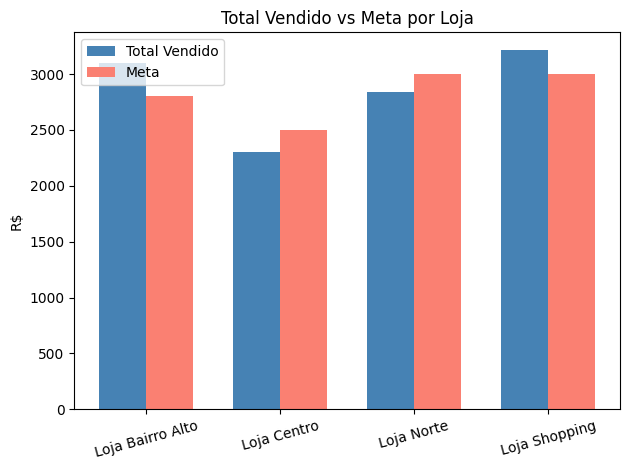

In [7]:
# Comparação: total vendido vs meta por loja
x = range(len(resultado_metas))
largura = 0.35

plt.bar([i - largura/2 for i in x],
        resultado_metas['Total_Vendido'], largura,
        label='Total Vendido', color='steelblue')
plt.bar([i + largura/2 for i in x],
        resultado_metas['Meta_Periodo'], largura,
        label='Meta', color='salmon')

plt.xticks(list(x), resultado_metas['Loja'], rotation=15)
plt.title('Total Vendido vs Meta por Loja')
plt.ylabel('R$')
plt.legend()
plt.tight_layout()
plt.show()

---
### O que este gráfico mostra?

Para cada loja, duas barras lado a lado: total vendido (azul) e meta (salmão). Quando a barra azul ultrapassa a salmão, a meta foi atingida.

### Por que isso importa?

Em varejo, **comparar realizado vs meta** é um dos relatórios mais solicitados pela gestão. O `merge` permite fazer essa comparação de forma automática — sem precisar cruzar tabelas manualmente no Excel.

In [8]:
# ── left join: todos de A, NaN onde B não tem match ──────────────────────
# Exemplo: enriquecendo cada venda com a margem da sua categoria

df_enriquecido = pd.merge(
    df,
    margem_cat,
    on='Categoria',
    how='left'        # mantém todas as linhas de df (esquerda)
)

# Calculando lucro estimado
df_enriquecido['Lucro_Estimado'] = (
    df_enriquecido['Valor Líquido'] * df_enriquecido['Margem_Pct']
).round(2)

print(f"Linhas originais: {len(df)} | Após merge: {len(df_enriquecido)}")
print()
print("Primeiras 5 linhas com margem:")
print(df_enriquecido[['Data', 'Categoria', 'Valor Líquido', 'Margem_Pct', 'Lucro_Estimado']].head(5).to_string(index=False))
print()
print(f"Lucro total estimado: R$ {df_enriquecido['Lucro_Estimado'].sum():,.2f}")

Linhas originais: 250 | Após merge: 250

Primeiras 5 linhas com margem:
      Data  Categoria  Valor Líquido  Margem_Pct  Lucro_Estimado
2026-01-04 Laticínios          94.12        0.28           26.35
2026-01-04  Mercearia          27.88        0.32            8.92
2026-02-27    Padaria          61.46        0.45           27.66
2026-01-12 Laticínios          36.14        0.28           10.12
2026-05-05 Laticínios         126.49        0.28           35.42

Lucro total estimado: R$ 3,706.57


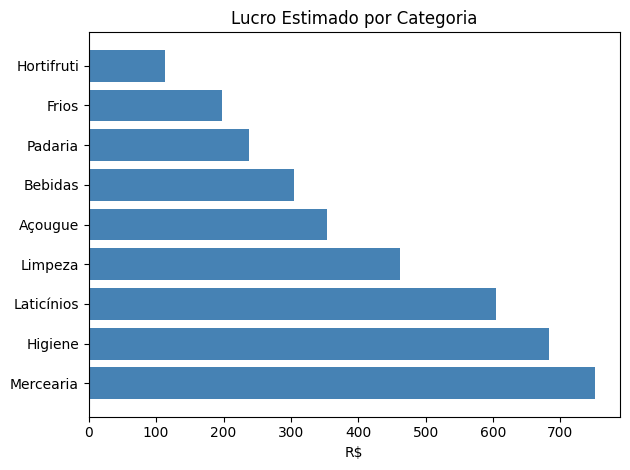

In [9]:
# Lucro estimado por categoria
lucro_cat = df_enriquecido.groupby('Categoria')['Lucro_Estimado'].sum().sort_values(ascending=False)

plt.barh(lucro_cat.index, lucro_cat.values, color='steelblue')
plt.title('Lucro Estimado por Categoria')
plt.xlabel('R$')
plt.tight_layout()
plt.show()

## Bloco 3 — Pipeline Completo de Limpeza

### O que é um pipeline de dados?

Um **pipeline** é uma sequência de passos bem definidos que transforma dados brutos em dados prontos para análise. Como uma linha de montagem: cada etapa faz uma coisa específica e passa o resultado para a próxima.

### Nosso pipeline da Semana 06:

```
Dados brutos
   ↓
1. Remoção de duplicatas
   ↓
2. Tratamento de missings
   ↓
3. Detecção e remoção de outliers
   ↓
4. Criação de colunas derivadas
   ↓
5. Enriquecimento com dados externos (merge)
   ↓
Dados prontos para análise
```

Agora vamos executar esse pipeline completo em um dataset "sujo" criado do zero.

In [10]:
# ── Criando um dataset sujo para o pipeline ────────────────────────────────
np.random.seed(55)
df_raw = df.copy()

# 1. Inserir NaN
for col, n in [('Categoria', 10), ('Preço Unitário', 8), ('Forma de Pagamento', 7)]:
    idx = np.random.choice(df_raw.index, n, replace=False)
    df_raw.loc[idx, col] = np.nan

# 2. Inserir duplicatas
dup = df_raw.sample(8, random_state=11)
df_raw = pd.concat([df_raw, dup], ignore_index=True).sample(frac=1, random_state=22).reset_index(drop=True)

# 3. Inserir outliers
idx_out = np.random.choice(df_raw.index, 5, replace=False)
df_raw.loc[idx_out[:3], 'Valor Líquido'] = [1500.0, 2000.0, 1800.0]
df_raw.loc[idx_out[3:], 'Valor Líquido'] = [0.10, 0.05]

print("=== Dataset Bruto (simulado) ===")
print(f"Linhas      : {len(df_raw)}")
print(f"NaN total   : {df_raw.isnull().sum().sum()}")
print(f"Duplicatas  : {df_raw.duplicated().sum()}")
print()
print("NaN por coluna:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0].to_string())

=== Dataset Bruto (simulado) ===
Linhas      : 258
NaN total   : 26
Duplicatas  : 8

NaN por coluna:
Categoria             10
Preço Unitário         9
Forma de Pagamento     7


In [11]:
# ── PIPELINE COMPLETO ──────────────────────────────────────────────────────

print("=" * 50)
print("PIPELINE DE LIMPEZA — BASE VENDAS SUPERMERCADO")
print("=" * 50)

df_clean = df_raw.copy()

# ── PASSO 1: Remover duplicatas ────────────────────
antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"\nPasso 1 — Duplicatas")
print(f"  Removidas: {antes - len(df_clean)} | Restam: {len(df_clean)} linhas")

# ── PASSO 2: Tratar missings ───────────────────────
nan_antes = df_clean.isnull().sum().sum()
df_clean['Categoria']          = df_clean['Categoria'].fillna(df_clean['Categoria'].mode()[0])
df_clean['Forma de Pagamento'] = df_clean['Forma de Pagamento'].fillna(df_clean['Forma de Pagamento'].mode()[0])
df_clean['Preço Unitário']     = df_clean['Preço Unitário'].fillna(df_clean['Preço Unitário'].median())
nan_depois = df_clean.isnull().sum().sum()
print(f"\nPasso 2 — Missings")
print(f"  NaN tratados: {nan_antes - nan_depois} | Restam: {nan_depois}")

# ── PASSO 3: Remover outliers (IQR) ───────────────
Q1  = df_clean['Valor Líquido'].quantile(0.25)
Q3  = df_clean['Valor Líquido'].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
lim_inf = Q1 - 1.5 * IQR

antes = len(df_clean)
df_clean = df_clean[df_clean['Valor Líquido'].between(lim_inf, lim_sup)]
print(f"\nPasso 3 — Outliers (Valor Líquido)")
print(f"  Removidos: {antes - len(df_clean)} | Restam: {len(df_clean)} linhas")

# ── PASSO 4: Criar colunas derivadas ──────────────
df_clean['Mês']          = df_clean['Data'].dt.month
df_clean['Dia_Semana']   = df_clean['Data'].dt.day_name()
df_clean['Faixa_Ticket'] = pd.cut(df_clean['Valor Líquido'],
                                   bins=[0, 20, 60, 120, 9999],
                                   labels=['Baixo','Médio','Alto','Premium'])
print(f"\nPasso 4 — Colunas derivadas criadas: Mês, Dia_Semana, Faixa_Ticket")

# ── PASSO 5: Enriquecer com margem (merge) ─────────
df_clean = pd.merge(df_clean, margem_cat, on='Categoria', how='left')
df_clean['Lucro_Estimado'] = (df_clean['Valor Líquido'] * df_clean['Margem_Pct']).round(2)
print(f"Passo 5 — Merge com tabela de margens concluído")

print(f"\n{'='*50}")
print(f"RESULTADO FINAL: {len(df_clean)} linhas x {df_clean.shape[1]} colunas")
print(f"NaN restantes: {df_clean.isnull().sum().sum()}")
print(f"Duplicatas restantes: {df_clean.duplicated().sum()}")

PIPELINE DE LIMPEZA — BASE VENDAS SUPERMERCADO

Passo 1 — Duplicatas
  Removidas: 8 | Restam: 250 linhas

Passo 2 — Missings
  NaN tratados: 25 | Restam: 0

Passo 3 — Outliers (Valor Líquido)
  Removidos: 13 | Restam: 237 linhas

Passo 4 — Colunas derivadas criadas: Mês, Dia_Semana, Faixa_Ticket
Passo 5 — Merge com tabela de margens concluído

RESULTADO FINAL: 237 linhas x 18 colunas
NaN restantes: 0
Duplicatas restantes: 0


In [12]:
# ── Análise final do dataset limpo ─────────────────────────────────────────
print("=== Análise do Dataset Limpo ===")
print()

# Top 5 produtos por lucro estimado
top_prod = df_clean.groupby('Produto')['Lucro_Estimado'].sum().sort_values(ascending=False).head(5)
print("Top 5 Produtos por Lucro Estimado:")
for prod, lucro in top_prod.items():
    print(f"  {prod:<30} R$ {lucro:,.2f}")

print()
# Faturamento e lucro por loja
resumo_loja = df_clean.groupby('Loja').agg(
    Vendas=('Valor Líquido', 'sum'),
    Lucro=('Lucro_Estimado', 'sum'),
    Transacoes=('Valor Líquido', 'count')
).round(2)
print("Resumo por Loja:")
print(resumo_loja.to_string())

=== Análise do Dataset Limpo ===

Top 5 Produtos por Lucro Estimado:
  Shampoo 350ml                  R$ 329.26
  Sabão em Pó 1,6kg              R$ 316.26
  Manteiga 200g                  R$ 205.62
  Carne Moída 1kg                R$ 203.70
  Feijão Carioca 1kg             R$ 167.16

Resumo por Loja:
                   Vendas   Lucro  Transacoes
Loja                                         
Loja Bairro Alto  2493.40  777.04          61
Loja Centro       2021.13  666.15          59
Loja Norte        2476.85  767.88          58
Loja Shopping     2657.82  892.31          59


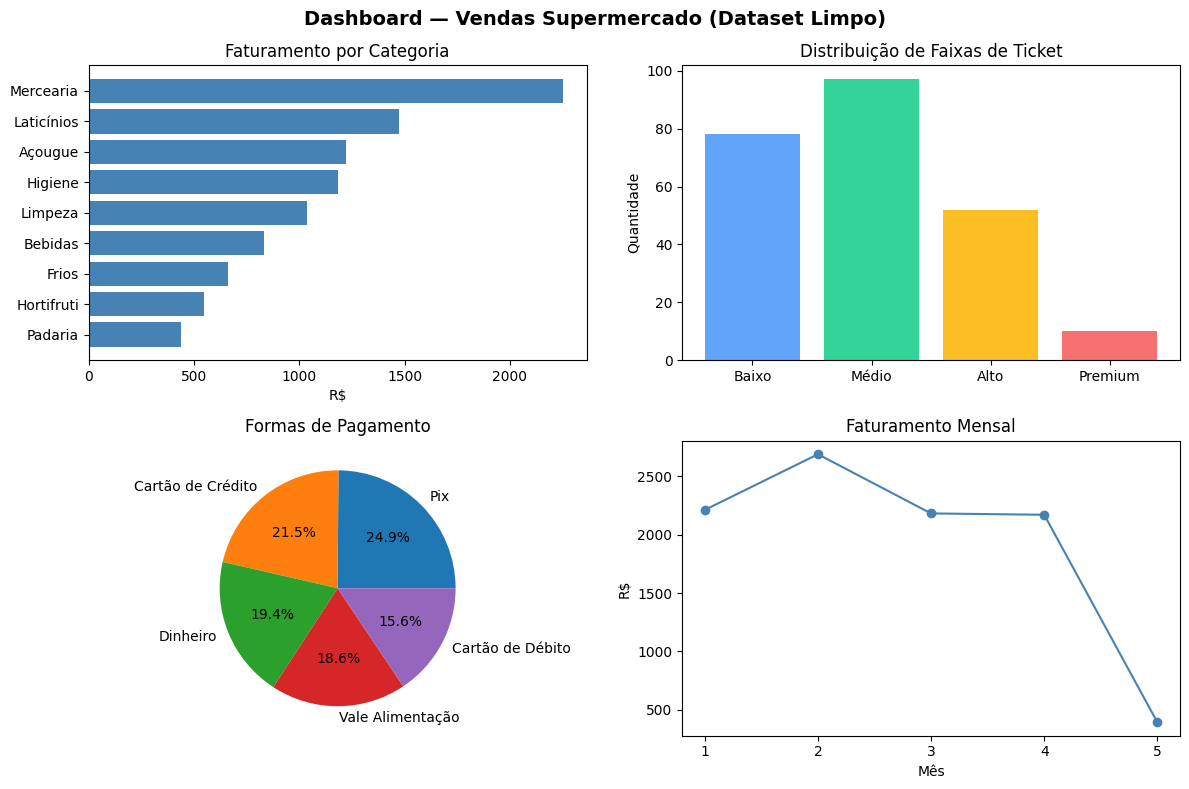

In [13]:
# Dashboard final: 4 gráficos em um
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Dashboard — Vendas Supermercado (Dataset Limpo)', fontsize=14, fontweight='bold')

# 1. Faturamento por Categoria
fat_cat = df_clean.groupby('Categoria')['Valor Líquido'].sum().sort_values()
axes[0, 0].barh(fat_cat.index, fat_cat.values, color='steelblue')
axes[0, 0].set_title('Faturamento por Categoria')
axes[0, 0].set_xlabel('R$')

# 2. Faixas de Ticket
faixas = df_clean['Faixa_Ticket'].value_counts().sort_index()
cores = ['#60a5fa', '#34d399', '#fbbf24', '#f87171']
axes[0, 1].bar(faixas.index, faixas.values, color=cores[:len(faixas)])
axes[0, 1].set_title('Distribuição de Faixas de Ticket')
axes[0, 1].set_ylabel('Quantidade')

# 3. Forma de Pagamento
pag = df_clean['Forma de Pagamento'].value_counts()
axes[1, 0].pie(pag.values, labels=pag.index, autopct='%1.1f%%')
axes[1, 0].set_title('Formas de Pagamento')

# 4. Vendas mensais
vendas_mes = df_clean.groupby('Mês')['Valor Líquido'].sum()
axes[1, 1].plot(vendas_mes.index, vendas_mes.values, marker='o', color='steelblue')
axes[1, 1].set_title('Faturamento Mensal')
axes[1, 1].set_xlabel('Mês')
axes[1, 1].set_ylabel('R$')
axes[1, 1].set_xticks(vendas_mes.index)

plt.tight_layout()
plt.show()

---
### O que este dashboard mostra?

Quatro visões complementares dos dados limpos:

1. **Faturamento por Categoria** — quais produtos geram mais receita
2. **Faixas de Ticket** — como se distribui o valor das compras
3. **Formas de Pagamento** — qual o método preferido dos clientes
4. **Faturamento Mensal** — tendência ao longo do tempo

### Por que isso importa?

Este é o ponto de chegada de toda a semana: você partiu de um dado bruto, com problemas de qualidade, e chegou a um dashboard limpo e informativo. Esse é exatamente o fluxo real de trabalho de um analista de dados.

## Exercício de Revisão — Semana 06

Este exercício integra todos os tópicos da semana. Use a base `base_vendas_supermercado.xlsx`.

### Cenário
Você foi contratado para analisar as vendas do supermercado. O arquivo chegou com problemas e você precisa limpá-lo antes de entregar o relatório ao gerente.

### Passos

1. **Carregue** a base e crie uma versão suja:
   - Insira 10 NaN em `'Categoria'` e 8 NaN em `'Quantidade'`
   - Insira 5 valores absurdos em `'Valor Líquido'` (ex: R$ 5000, R$ 0.01)
   - Duplique 7 linhas aleatórias

2. **Diagnóstico**: exiba um relatório com:
   - % de NaN por coluna
   - Número de duplicatas
   - Limites IQR para `'Valor Líquido'` (inferior e superior)

3. **Limpeza completa**:
   - Remova duplicatas
   - Preencha NaN de `'Categoria'` com a moda
   - Preencha NaN de `'Quantidade'` com a mediana
   - Remova outliers de `'Valor Líquido'` pelo método IQR

4. **Transformações**:
   - Crie a coluna `'Mes_Nome'` com o nome do mês (ex: "January")
   - Crie a coluna `'Perfil_Compra'` com `pd.cut()` em 3 faixas de `'Valor Líquido'`
   - Crie a coluna `'Tem_Desconto'` com `np.where()`

5. **Enriquecimento**:
   - Crie uma tabela de metas mensais por loja (defina valores à sua escolha)
   - Faça um `merge` do resumo mensal de vendas com essa tabela de metas
   - Identifique quais lojas atingiram a meta em cada mês

6. **Relatório final**: plote um gráfico mostrando o total de vendas por loja e mês.

## Gabarito — Resumo dos Pontos Principais

### Passo 1 — Criando dados sujos
```python
np.random.seed(42)
df_raw = df.copy()
for col, n in [('Categoria', 10), ('Quantidade', 8)]:
    idx = np.random.choice(df_raw.index, n, replace=False)
    df_raw.loc[idx, col] = np.nan
idx_out = np.random.choice(df_raw.index, 5, replace=False)
df_raw.loc[idx_out[:3], 'Valor Líquido'] = [5000, 4500, 3800]
df_raw.loc[idx_out[3:], 'Valor Líquido'] = [0.01, 0.05]
dup = df_raw.sample(7, random_state=1)
df_raw = pd.concat([df_raw, dup], ignore_index=True)
```

### Passo 3 — Pipeline de limpeza
```python
df_clean = df_raw.drop_duplicates()
df_clean['Categoria'] = df_clean['Categoria'].fillna(df_clean['Categoria'].mode()[0])
df_clean['Quantidade'] = df_clean['Quantidade'].fillna(df_clean['Quantidade'].median())
Q1, Q3 = df_clean['Valor Líquido'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df_clean = df_clean[df_clean['Valor Líquido'].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)]
```

### Passo 4 — Transformações
```python
df_clean['Mes_Nome']      = df_clean['Data'].dt.month_name()
df_clean['Perfil_Compra'] = pd.cut(df_clean['Valor Líquido'],
                                   bins=[0, 25, 80, 9999],
                                   labels=['Pequeno','Médio','Grande'])
df_clean['Tem_Desconto']  = np.where(df_clean['Desconto %'] > 0, 'Sim', 'Não')
```

### Passo 5 — Merge com metas
```python
metas = pd.DataFrame({'Loja': ['Loja Shopping','Loja Centro','Loja Norte','Loja Bairro Alto'],
                      'Meta': [5000, 4500, 3800, 3500]})
vendas_loja = df_clean.groupby('Loja')['Valor Líquido'].sum().reset_index()
vendas_loja.columns = ['Loja', 'Total']
resultado = pd.merge(vendas_loja, metas, on='Loja')
resultado['Atingiu'] = resultado['Total'] >= resultado['Meta']
```

## Fechamento da Semana 06

**Parabéns!** Você completou a semana de Limpeza e Transformação de Dados. Aqui está o que você aprendeu:

### Resumo dos tópicos

| Tópico | O que você sabe fazer |
|---|---|
| **Missings** | Detectar com `isnull()`, tratar com `fillna()`, `dropna()`, `ffill()` |
| **Duplicatas** | Identificar com `duplicated()`, remover com `drop_duplicates()` |
| **Outliers** | Visualizar com boxplot, detectar com IQR, tratar com capping ou remoção |
| **Normalização** | Min-Max e Z-Score sem dependências externas |
| **Funções** | `apply()` com lambda e funções personalizadas |
| **Faixas** | `pd.cut()` e `pd.qcut()` para segmentação |
| **Condicionais** | `np.where()` e `np.select()` vetorizados |
| **Concatenação** | `pd.concat()` para empilhar DataFrames |
| **Merge/Join** | `pd.merge()` com inner, left, right, outer |
| **Pipeline** | Construir um fluxo completo do dado bruto ao limpo |

---
**Próxima semana:** Visualizações avançadas com Seaborn e Plotly — gráficos profissionais e interativos.